# FIT5196 A1 — WIP notebook (Echo) · Task 1: parse, profile, map

**Group001** · Echo Zhao (ezha0053) · work package WP1 — rubric A1, A2, E2.

This is a personal working notebook (`01_WIP/`), **not** a deliverable. Sections are numbered
to match `A1_solution_template.ipynb` verbatim (decision D4) so that finished cells can be
lifted into `Group001_solution.ipynb` without renumbering, and so the mapping CSV's
`notebook_evidence` column can cite stable section names.

**What this notebook must produce by Mon 25 Aug:** `parse_json()` and `parse_xml()` returning
flat tables that Jasmine can build the six relational tables from.

## 0. Configuration and reproducibility

All configurable paths live here. The final notebook must run with **Restart and Run All**
with no manual edits and no network access.

In [1]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/5196/Group001_A1/01_WIP
except ImportError:
    pass   # not on Colab

In [2]:
from pathlib import Path

GROUP_ID = "Group001"

# Where the raw JSON/XML live. The first candidate that exists wins.
# The marker's layout is listed first, so the submitted notebook works unchanged for them.
INPUT_CANDIDATES = [
    Path("raw_input"),                       # marker unzips the submission and runs here
    Path("../Group001_A1/raw_input"),        # Echo's Mac: notebook sits in echo_branch/
    Path("Group001_A1/raw_input"),           # repo root
    Path("../DATA/Group001_A1/raw_input"),   # Drive, run from 00_Master/
]
INPUT_DIR = next((p for p in INPUT_CANDIDATES if p.exists()), None)
assert INPUT_DIR is not None, f"No input folder found. Tried: {INPUT_CANDIDATES}"

JSON_PATH = INPUT_DIR / f"{GROUP_ID}_commerce.json"
XML_PATH  = INPUT_DIR / f"{GROUP_ID}_operations.xml"
DICT_PATH = INPUT_DIR.parent / "public_data_dictionary.csv"

# Personal runs write to a personal scratch folder (decision D9):
# only a full run of 00_Master/Group001_solution.ipynb may write to the shared 02_Outputs/.
OUTPUT_DIR = Path("outputs_wip_echo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Reading from :", INPUT_DIR.resolve())
print("Writing to   :", OUTPUT_DIR.resolve())

Reading from : /Users/ez_us/Documents/5196/5196-A1/Group001_A1/raw_input
Writing to   : /Users/ez_us/Documents/5196/5196-A1/echo_branch/outputs_wip_echo


Colab only. This cell is deliberately separate so the configuration cell above stays
path-neutral (spec Appendix A bans student-specific absolute paths). It does nothing off Colab.

### 0.1 Environment and dependencies

Standard library plus pandas only. Nothing here needs installing on Colab, which keeps the
submitted notebook dependency-free apart from pandas.

In [3]:
import json
import re
import xml.etree.ElementTree as ET

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print("pandas", pd.__version__)

pandas 3.0.5


## 1. Parse and profile the two sources

**Parser contract (agreed 22 Aug).** `parse_json()` and `parse_xml()` each return a dict of
flat `DataFrame`s keyed by output-table name, plus the file's export metadata.

Jasmine need create six tables according to this work:
   1. orders
   2. order_items
   3. customers
   4. deliveries
   5. products
   6. product_reviews

Two rules keep the contract honest:

1. **Column names** — renamed to the `public_data_dictionary.csv` field names, so
   both sources come out with the same column names and can be concatenated without a lookup.
   Three text fields keep a `_raw` suffix (`customer_note_raw`, `review_body_raw`,
   `product_description_raw`) because the target field is the *cleaned* version, produced later
   by ***Shawn's*** text functions.
2. **Values Consistence** — exactly as they appear in the file. XML dates are still
   `DD/MM/YYYY`, money is still `"AUD 2,765.47"`, booleans are still `"Y"`/`"N"`. Type and
   format normalisation is a separate, visible step (§1.3), not something hidden inside the
   parser.

Rule 2 matters for marks: rubric A1 asks for evidence of formats and missing-value conventions,
and that evidence disappears if the parser silently repairs everything on the way in.

Every returned frame carries a `source_system` column (`"JSON"` / `"XML"`) — needed for the
overlap and reconciliation work in §5, and for row-flow evidence in §6.

### 1.1 JSON structure and profile

**Structure**
1. what the top-level keys are, 
2. how many records sit under each, 
3. and which parts are nested. 
This is the evidence behind the "source grains and nested structures" requirement in A1.

In [4]:
with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_json = json.load(f)

print("Top-level keys :", list(raw_json.keys()))
print("Export metadata:", raw_json["exportMetadata"])

for key in ["customerProfiles", "orders", "productReviews"]:
    # print(f"{key} {len(raw_json[key])} records")
    print(f"{key:18s} {len(raw_json[key]):,} records")
    # ":18s" means "left-justify in a field 18 characters wide", and ">6," means "right-justify in a field 6 characters wide, with commas as thousands separators"
    # why not just use f"{len(raw_json[key]):,}"? Because that would right-justify in a field only as wide as the number itself, which is less readable when the numbers have different lengths. This way, the numbers line up nicely in a column.

# One order shows the nesting: a flat header, a repeated cart, a single delivery.
# "grain" comes from 'public_data_dictionary.csv' and means "the level of detail represented by one row of the table".
first_order = raw_json["orders"][0]
print("\nAn order contains:", list(first_order.keys()))
print("  header       ->", len(first_order["header"]), "fields  (grain: one row per order)")
print("  shoppingCart ->", len(first_order["shoppingCart"]), "items   (grain: one row per order item)")
print("  delivery     ->", len(first_order["delivery"]), "fields  (grain: one row per order)")

Top-level keys : ['customerProfiles', 'exportMetadata', 'orders', 'productReviews']
Export metadata: {'groupAlias': 'Group001', 'period': 2018, 'sourceSystem': 'CommercePlatform'}
customerProfiles   500 records
orders             2,818 records
productReviews     3,946 records

An order contains: ['delivery', 'header', 'shoppingCart']
  header       -> 22 fields  (grain: one row per order)
  shoppingCart -> 2 items   (grain: one row per order item)
  delivery     -> 20 fields  (grain: one row per order)


#### **Naming helper.** 
JSON keys are <font color = "#189AB4">camelCase</font>; the data dictionary is <font color = "#189AB4">snake_case</font>. 

In [5]:
def to_snake(name, exceptions=None):
    """camelCase -> snake_case. 'ID' is treated as one word, so customerID -> customer_id.
    `exceptions` maps a source key straight to its final name, bypassing the rule."""
    exceptions = exceptions or {}
    if name in exceptions:
        return exceptions[name]
    name = name.replace("ID", "Id")
    name = re.sub(r"(?<!^)(?=[A-Z])", "_", name)
    return name.lower()

In [6]:
def check_names(tables, dictionary_path):
    """Every column we produce must be a dictionary field, or be explained.

    Prints two lists per table, which mean different things:
      produced but not a target field -> either the naming rule is wrong,
                                         or it is a raw text input to a derived field
      target field with no source key -> a derived field (mapping source_format = 'derived')
    """
    d = pd.read_csv(dictionary_path, keep_default_na=False)
    target = {t: set(g.field_name) for t, g in d.groupby("output_table")}
    for name, df in tables.items():
        if name not in target:
            print(f"-- {name}: not an output table (kept for analysis only)")
            continue
        cols = set(df.columns) - {"source_system"}
        print(f"-- {name}")
        print("   produced but not a target field:", sorted(cols - target[name]) or "none")
        print("   target field with no source key:", sorted(target[name] - cols) or "none")

### **The parser.** 
Walk the orders once, appending to three lists; 

the two stand-alone arrays go straight to DataFrames.

`customers` and `product_reviews` come only from this file — there are no products here.

In [7]:
def parse_json(path, exceptions=None):
    """Read the commerce JSON export and return flat tables with source-native values.

    Returns
    -------
    tables : dict of str -> DataFrame   keys: orders, order_items, deliveries,
                                              customers, product_reviews
    metadata : dict                     the file's exportMetadata block
    """
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    def rename(record):
        return {to_snake(k, exceptions): v for k, v in record.items()}

    orders, order_items, deliveries = [], [], []
    for order in raw["orders"]:
        orders.append(rename(order["header"]))
        deliveries.append(rename(order["delivery"]))
        order_items.extend(rename(item) for item in order["shoppingCart"])

    tables = {
        "orders":          pd.DataFrame(orders),
        "order_items":     pd.DataFrame(order_items),
        "deliveries":      pd.DataFrame(deliveries),
        "customers":       pd.DataFrame([rename(c) for c in raw["customerProfiles"]]),
        "product_reviews": pd.DataFrame([rename(r) for r in raw["productReviews"]]),
    }
    for df in tables.values():
        df.insert(0, "source_system", "JSON")

    return tables, raw["exportMetadata"]

In [8]:
# Pass 1 — the general rule alone. Nothing assumed about exceptions.
naive_tables, _ = parse_json(JSON_PATH)
check_names(naive_tables, DICT_PATH)

-- orders
   produced but not a target field: ['customer_note']
   target field with no source key: ['customer_note_clean', 'promo_code']
-- order_items
   produced but not a target field: none
   target field with no source key: none
-- deliveries
   produced but not a target field: none
   target field with no source key: none
-- customers
   produced but not a target field: ['prior12_m_orders']
   target field with no source key: ['prior_12m_orders']
-- product_reviews
   produced but not a target field: ['review_text']
   target field with no source key: ['contains_non_latin_script', 'extracted_order_reference', 'extracted_product_sku', 'review_body_clean', 'review_body_latin_analysis', 'review_length_chars', 'review_word_count']


READ ITS OUTPUT. - "customers" and "product_reviews"

In [9]:
# Written from the report above, not before it.
NAME_RULE_FIXES = {"prior12MOrders": "prior_12m_orders"}   # regex splits on capitals, not digits
RAW_TEXT_FIELDS = {"customerNote": "customer_note_raw",    # target field is the *clean* version
                   "reviewText":   "review_body_raw"}
JSON_NAME_EXCEPTIONS = {**NAME_RULE_FIXES, **RAW_TEXT_FIELDS}

In [10]:
# Pass 2 — corrected rule. What remains is expected, not an error.
json_tables, json_meta = parse_json(JSON_PATH, JSON_NAME_EXCEPTIONS)
check_names(json_tables, DICT_PATH)
del naive_tables

for name, df in json_tables.items():
    print(f"{name:16s} {df.shape[0]:,} rows x {df.shape[1]:>2} cols")

-- orders
   produced but not a target field: ['customer_note_raw']
   target field with no source key: ['customer_note_clean', 'promo_code']
-- order_items
   produced but not a target field: none
   target field with no source key: none
-- deliveries
   produced but not a target field: none
   target field with no source key: none
-- customers
   produced but not a target field: none
   target field with no source key: none
-- product_reviews
   produced but not a target field: ['review_body_raw']
   target field with no source key: ['contains_non_latin_script', 'extracted_order_reference', 'extracted_product_sku', 'review_body_clean', 'review_body_latin_analysis', 'review_length_chars', 'review_word_count']
orders           2,818 rows x 23 cols
order_items      8,826 rows x  7 cols
deliveries       2,818 rows x 21 cols
customers        500 rows x 21 cols
product_reviews  3,946 rows x 16 cols


**Profile.** 

Three questions per table: 

- is the intended business key unique, 
- what is missing,
- and what do the values actually look like. 

These answers become §1.3's assumptions and feed the `overlap_or_conflict_rule` column of the mapping.

In [11]:
# The dictionary declares the primary key of every output table: the field at position 1.
# Read it rather than retyping it, so the notebook and the dictionary cannot drift apart.
# Whether each declared key is *actually* unique in the data is tested in §1.3c.
DICTIONARY = pd.read_csv(DICT_PATH, keep_default_na=False)
DECLARED_KEYS = (DICTIONARY[DICTIONARY.position == 1]
                 .set_index("output_table")["field_name"].to_dict())
print(DECLARED_KEYS)


def profile(tables, source):
    """Per table: is the declared key unique, and how many columns hold a blank or null."""
    rows = []
    for name, key in DECLARED_KEYS.items():
        if name not in tables:
            continue
        df = tables[name]
        rows.append({"source": source, "table": name, "rows": len(df), "key": key,
                     "unique_keys": df[key].nunique(),
                     "duplicate_key_rows": len(df) - df[key].nunique(),
                     "cols_with_blank_or_null": int(((df == "") | df.isna()).any().sum())})
    return pd.DataFrame(rows)


profile(json_tables, "JSON")

{'orders': 'order_id', 'order_items': 'order_item_id', 'customers': 'customer_id', 'deliveries': 'delivery_id', 'products': 'product_id', 'product_reviews': 'review_id'}


,source,table,rows,key,unique_keys,duplicate_key_rows,cols_with_blank_or_null
0,JSON,orders,2818,order_id,2750,68,1
1,JSON,order_items,8826,order_item_id,8625,201,0
2,JSON,customers,500,customer_id,500,0,0
3,JSON,deliveries,2818,delivery_id,2750,68,0
4,JSON,product_reviews,3946,review_id,3850,96,0


In [12]:
# What do the "missing" values actually look like? The spec cares about the exact convention.
for name, df in json_tables.items():
    blanks = ((df == "") | df.isna()).sum()
    blanks = blanks[blanks > 0]
    if len(blanks):
        print(f"{name}:")
        for col, n in blanks.items():
            sample = df.loc[(df[col] == "") | df[col].isna(), col].iloc[0]
            print(f"   {col:10s} {n:>5,} rows   example value: {sample!r}")

orders:
   coupon_code 1,767 rows   example value: ''


In [13]:
# Value shapes, so §1.3 can compare JSON against XML field by field.
print(json_tables["orders"][["order_timestamp", "order_price", "coupon_discount",
                             "expedited_delivery", "currency"]].head(3).to_string(index=False))
print()
print(json_tables["deliveries"][["dispatch_date", "delivered_date", "on_time_in_full"]].head(3).to_string(index=False))
print()
print("dtypes (orders):")
print(json_tables["orders"].dtypes.to_string())

    order_timestamp  order_price  coupon_discount  expedited_delivery currency
2018-12-31 13:52:00      1189.23               10                True      AUD
2018-08-23 14:56:00      1554.14               25                True      AUD
2018-09-24 08:07:00      4732.56               10               False      AUD

dispatch_date delivered_date  on_time_in_full
   2019-01-01     2019-01-08            False
   2018-08-26     2018-09-01             True
   2018-09-25     2018-09-30            False

dtypes (orders):
source_system                  str
coupon_code                    str
coupon_discount              int64
currency                       str
customer_id                    str
customer_lat               float64
customer_long              float64
customer_note_raw              str
delivery_charges           float64
device_type                    str
expedited_delivery            bool
nearest_warehouse              str
order_id                       str
order_price               

### 1.2 XML structure and profile

**Why I need it.** 

Task 1 requires the grain, nesting and key structure of *both* sources. The
XML is the harder half: it carries two tables the JSON does not have (`products`, and a
warehouse directory), and every value arrives as text.

**What it is.** 

The same contract as §1.1 — `parse_xml()` returns flat DataFrames keyed by
output-table name, canonical column names, source-native values (DEC-011).

**How I get it.

** `xml.etree.ElementTree`, a structured parser. 

The spec forbids treating either document as plain text for regex, so no string scraping anywhere in this section.

**Why the others care.** 

This is the only source of `products`, which Jasmine cannot build
without it, and the only place the `DD/MM/YYYY`, `AUD 2,765.47`, `Y/N` and `10%` formats appear
— every one of which becomes a normalisation rule she writes and Yandu validates.

#### Structure survey

**Why** 

State the shape before flattening it, so the flattening is a consequence of evidence rather than of my assumptions about the file.

**What** 

The root element and its attributes, the five collections beneath it and their
sizes, and the internal shape of one `Order`. - Jasmine notice

**How**

`.findall()` with a path, then count. No DataFrames yet — this is inspection.

**So what** 

The counts here are the denominator for every row-flow check in §6.
If 2,818 orders go in and 2,750 come out, *Yandu* has to be able to point at this cell.

In [14]:
root = ET.parse(XML_PATH).getroot()

print("Root element   :", root.tag)
print("Root attributes:", root.attrib)          # groupAlias / sourceSystem / period

for child in root:
    print(f"  {child.tag:20s} {len(list(child)):>6,} children")

# One order, to show the nesting. Compare with the JSON: same three parts, different names.
order = root.find("Orders/Order")
print("\nAn Order contains:", [part.tag for part in order])
print("  Header        ->", len(list(order.find("Header"))), "fields  (grain: one row per order)")
print("  Shopping_Cart ->", len(order.findall("Shopping_Cart/Item")), "Item(s) (grain: one row per order item)")
print("  Delivery      ->", len(list(order.find("Delivery"))), "fields  (grain: one row per order)")

# WarehouseDirectory has no matching output table. Noted now so it is not silently dropped.
print("\nWarehouse fields:", [f.tag for f in root.find("WarehouseDirectory/Warehouse")])

Root element   : OperationsExport
Root attributes: {'groupAlias': 'Group001', 'sourceSystem': 'OperationsERP', 'period': '2018'}
  Export_Metadata           2 children
  Orders                2,818 children
  ProductCatalogue      1,000 children
  ProductReviews        3,946 children
  WarehouseDirectory        3 children

An Order contains: ['Header', 'Shopping_Cart', 'Delivery']
  Header        -> 22 fields  (grain: one row per order)
  Shopping_Cart -> 1 Item(s) (grain: one row per order item)
  Delivery      -> 20 fields  (grain: one row per order)

Warehouse fields: ['Name', 'Latitude', 'Longitude']


#### Naming rule and the parser

**Why I need it.** The XML uses `Title_Case_With_Underscores`; the data dictionary uses
`snake_case`. A rule is needed.

**What it is.** 
1. `Order_ID` → `order_id` use `.lower()` — RECALL the JSON's
camelCase regex.
2. `element_to_record` turns one element's children into a dict; 
3. `parse_xml` walks the tree and stacks those dicts.

**How I get it.** 
`(child.text or "")` reads each leaf. The `or ""` is DEC-015: an empty XML
element gives `None`, while the JSON export gives `""` for the same absent value. (SHAWN NOTE HERE! The decision is made by human )
Without it the
two sources are not comparable and every blank count reports a false difference.

**Why the others care.** `exceptions` is keyed on the **original tag**, not the lowered name, so
the JSON and XML exception tables are not interchangeable — Shawn will look for that in review.
And `warehouses` is returned but is *not* an output table: it must never become a column in the
six CSVs. It is kept because it carries lat/long, which is useful for an EDA distance figure.

In [15]:
def element_to_record(element, exceptions=None):
    """One XML element -> one dict. Child tag becomes the column, child text becomes the value.

    `exceptions` maps an original tag (e.g. "Review_Text") straight to its final column name,
    bypassing the .lower() rule. Text is read as `child.text or ""` — see DEC-015.
    """
    exceptions = exceptions or {}
    return {exceptions.get(child.tag, child.tag.lower()): (child.text or "")
            for child in element}


def parse_xml(path, exceptions=None):
    """Read the operations XML export and return flat tables with source-native values.

    Returns
    -------
    tables : dict of str -> DataFrame   orders, order_items, deliveries, products,
                                        product_reviews, warehouses (not an output table)
    metadata : dict                     root attributes plus the Export_Metadata block
    """
    root = ET.parse(path).getroot()

    orders, order_items, deliveries = [], [], []
    for order in root.findall("Orders/Order"):
        orders.append(element_to_record(order.find("Header"), exceptions))
        deliveries.append(element_to_record(order.find("Delivery"), exceptions))
        order_items.extend(element_to_record(item, exceptions)
                           for item in order.findall("Shopping_Cart/Item"))

    tables = {
        "orders":          pd.DataFrame(orders),
        "order_items":     pd.DataFrame(order_items),
        "deliveries":      pd.DataFrame(deliveries),
        "products":        pd.DataFrame([element_to_record(p, exceptions)
                                         for p in root.findall("ProductCatalogue/Product")]),
        "product_reviews": pd.DataFrame([element_to_record(r, exceptions)
                                         for r in root.findall("ProductReviews/Review")]),
        "warehouses":      pd.DataFrame([element_to_record(w, exceptions)
                                         for w in root.findall("WarehouseDirectory/Warehouse")]),
    }
    for df in tables.values():
        df.insert(0, "source_system", "XML")

    metadata = dict(root.attrib)
    metadata.update(element_to_record(root.find("Export_Metadata")))
    return tables, metadata

#### Pass 1 — the general rule alone

**Why I need it.** DEC-012. Encoding the exceptions before running the rule would leave no
evidence of how they were found, and a reviewer could not tell a bug from a design choice.

**What it is.** `parse_xml` with no exceptions, checked against the data dictionary.

**How I get it.** The same `check_names` defined in §1.1 — reused, not rewritten, so the JSON
and XML sides are judged by identical criteria.

**Why the others care.** The right-hand list of this output is the derived-field inventory for
the XML side. Those are the `source_format = derived` rows Shawn and Jasmine own in the mapping.

In [16]:
naive_xml, _ = parse_xml(XML_PATH)
check_names(naive_xml, DICT_PATH)

-- orders
   produced but not a target field: ['customer_note']
   target field with no source key: ['customer_note_clean', 'promo_code']
-- order_items
   produced but not a target field: none
   target field with no source key: none
-- deliveries
   produced but not a target field: none
   target field with no source key: none
-- products
   produced but not a target field: ['product_description']
   target field with no source key: ['product_description_clean']
-- product_reviews
   produced but not a target field: ['review_text']
   target field with no source key: ['contains_non_latin_script', 'extracted_order_reference', 'extracted_product_sku', 'review_body_clean', 'review_body_latin_analysis', 'review_length_chars', 'review_word_count']
-- warehouses: not an output table (kept for analysis only)


#### Reading pass 1, and the exceptions it justifies

Three tags convert cleanly but land on the wrong side of the raw/clean boundary, and **no tag
breaks the `.lower()` rule** — unlike the JSON side, where `prior12MOrders` did. That asymmetry
is itself a finding: the XML's explicit underscores leave nothing for a rule to guess wrong.

| Tag | `.lower()` gives | Dictionary wants | Why an exception |
|---|---|---|---|
| `Customer_Note` | `customer_note` | `customer_note_clean`, `promo_code` | one field, two targets |
| `Review_Text` | `review_text` | seven(see the outcome last cell!) `product_reviews` fields | one field, seven targets |
| `Product_Description` | `product_description` | `product_description_clean` | one field, one cleaned target |

The left list is never renamed to a target — a source field that fans out to several targets has
no single correct target name. It is suffixed `_raw` to mark it as an *input* to derivation, and
the fan-out is recorded in the mapping CSV (DEC-014).

In [17]:
# Written from the pass-1 report above, not before it. Keys are original tags.
XML_NAME_EXCEPTIONS = {
    "Customer_Note":       "customer_note_raw",
    "Review_Text":         "review_body_raw",
    "Product_Description": "product_description_raw",
}

<a class="anchor" id="lab-task-1"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px">
<strong style="color:#FF5555">SHAWN NOTE: </strong>
Shawn, your text function should go the "_raw" fields as my understanding. XML has 3, and JSON has 2.</strong> in descending order.</div>


#### Pass 2 — the corrected rule

**Why I need it.** To show the fix worked, and to leave the clean run as the notebook's evidence.

**What it is.** `xml_tables` — the frames every later section uses.

**How I get it.** Re-parse with the exception table, re-run the same check, drop the pass-1 copy.

**Why the others care.** After this cell the two sources have identical column names for shared
tables, which is the precondition for the overlap work in §1.3 and the reconciliation in §5.

In [18]:
xml_tables, xml_meta = parse_xml(XML_PATH, XML_NAME_EXCEPTIONS)
check_names(xml_tables, DICT_PATH)
del naive_xml

print("\nExport metadata:", xml_meta)
for name, df in xml_tables.items():
    print(f"{name:16s} {df.shape[0]:,} rows x {df.shape[1]:>2} cols")

-- orders
   produced but not a target field: ['customer_note_raw']
   target field with no source key: ['customer_note_clean', 'promo_code']
-- order_items
   produced but not a target field: none
   target field with no source key: none
-- deliveries
   produced but not a target field: none
   target field with no source key: none
-- products
   produced but not a target field: ['product_description_raw']
   target field with no source key: ['product_description_clean']
-- product_reviews
   produced but not a target field: ['review_body_raw']
   target field with no source key: ['contains_non_latin_script', 'extracted_order_reference', 'extracted_product_sku', 'review_body_clean', 'review_body_latin_analysis', 'review_length_chars', 'review_word_count']
-- warehouses: not an output table (kept for analysis only)

Export metadata: {'groupAlias': 'Group001', 'sourceSystem': 'OperationsERP', 'period': '2018', 'system': 'OperationsERP', 'contract_version': 'A1-DATA-2.0'}
orders         

#### Profile

**Why I need it.** Task 1 asks for candidate keys, duplicate evidence and the date, boolean,
currency, percentage and missing-value formats. This is where each is shown rather than claimed.

**What it is.** Three checks: is the intended key unique, what is blank, and what do the values
literally look like.

**How I get it.** The same three cells as §1.1, run against `xml_tables` — deliberately identical
so §1.3 can put the two profiles side by side.

**Why the others care.** Every row of this output turns into work for someone: the duplicate
counts are Yandu's canonical-row problem (Q2), and each format below is a conversion Jasmine
writes and a `VAL-SCHEMA-` check Yandu runs.

<a class="anchor" id="SHOUTOUT"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px">
<strong style="color:#FF5555">JASMINE AND YANDU NOTE: </strong>
PLEASE understand the logic here</strong></div>


In [19]:
# The same profile function as §1.1, run on the XML — deliberately identical so §1.3 can put
# the two profiles side by side. `warehouses` is absent because it is not an output table.
profile(xml_tables, "XML")

,source,table,rows,key,unique_keys,duplicate_key_rows,cols_with_blank_or_null
0,XML,orders,2818,order_id,2750,68,1
1,XML,order_items,8833,order_item_id,8619,214,0
2,XML,deliveries,2818,delivery_id,2750,68,0
3,XML,products,1000,product_id,1000,0,0
4,XML,product_reviews,3946,review_id,3850,96,0


In [20]:
for name, df in xml_tables.items():
    blanks = (df == "").sum()
    blanks = blanks[blanks > 0]
    for col, n in blanks.items():
        print(f"{name}.{col:10s} {n:>6,} blank rows")

orders.coupon_code  1,770 blank rows


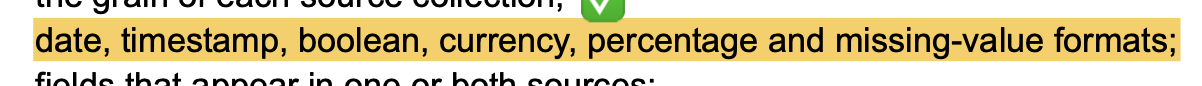

In [21]:
# The formats themselves — the evidence behind every normalisation rule in §1.3.
print(xml_tables["orders"][["order_timestamp", "order_price", "delivery_charges",
                            "coupon_discount", "expedited_delivery"]].head(3).to_string(index=False))
print()
print(xml_tables["products"][["unit_price", "launch_date", "recyclable_packaging"]].head(3).to_string(index=False))
print()
print("Every XML column arrives as text:", xml_tables["orders"].dtypes.unique())

    order_timestamp  order_price delivery_charges coupon_discount expedited_delivery
02/11/2018 08:50:00   AUD 155.15        AUD 12.90             10%                  N
18/07/2018 17:10:00   AUD 503.55        AUD 13.94              0%                  N
29/12/2018 20:59:00 AUD 1,827.30         AUD 8.66              0%                  N

  unit_price launch_date recyclable_packaging
AUD 2,765.47  01/07/2017                    Y
  AUD 455.28  12/01/2014                    Y
  AUD 472.24  01/02/2012                    Y

Every XML column arrives as text: [<StringDtype(storage='python', na_value=nan)>]


#### Hand-off note for §1.3

Two things §1.2 could not answer on its own. Both are settled below — this note stays so the
question and its answer sit together rather than the answer appearing without a question.

1. **Why do the `order_items` row counts differ (JSON 8,826, XML 8,833) when `orders` and
   `product_reviews` match exactly?**
   Answered in §1.3c and §1.3d. The counts differ because the two files carry different numbers
   of duplicated keys (201 JSON, 214 XML), and the matching counts elsewhere are a coincidence —
   the two files describe mostly *different* records. 15,685 distinct items exist across both.
2. **Are the duplicate rows field-identical?**
   Answered in §1.3c. Yes — every duplicated key is exactly two copies, and the copies match on
   every column. That is what makes the canonical-row rule deterministic rather than arbitrary.

### 1.3 Source comparison and assumptions

*(next working session — format table, within-source duplicates, cross-source overlap)*

**Why** 

Task 1 asks which fields appear in one or both sources, 
what the format conventions are,
where records duplicate within a source and overlap across sources, 
and which assumptions must hold before transformation. 
Everything below is one of those four. 

**What** 

Four findings and one assumptions register. 
No output tables are built here — that is Jasmine's §4.

**How** 

Compare the two dicts of frames produced by §1.1 and §1.2, 
using a small set of normalisers that exist only to make values comparable.

**So what** 

This section is the hand-off. 
<font color = '#DB6F3D'>***Jasmine***</font> gets the format rules and the normalisers,
<font color = '#DB6F3D'>***Yandu***</FONT> gets the duplicate and overlap counts his reconciliation must reproduce, 
<font color = '#DB6F3D'>***Shawn***</FONT> get confirmation that the raw text fields agree across sources.

#### 1.3a Field coverage and format conventions

**Why** 

table means <font color = '#DB6F3D'>***Jasmine***</font> does not have to rediscover them from the raw files.

**What** 

Which tables exist in which source, then the same value shown as each source writes it.

**How** 

Set arithmetic on the table keys, then one shared order printed from both frames.

**So what** 

Every row of the format table becomes exactly one conversion in §4 and one
`VAL-SCHEMA-` check in §6. If a row here has no matching check there, something was missed.

In [22]:
print("JSON tables:", sorted(json_tables))
print("XML  tables:", sorted(xml_tables))
print("JSON only  :", sorted(set(json_tables) - set(xml_tables)))
print("XML only   :", sorted(set(xml_tables) - set(json_tables)))

# Column coverage for the four tables both sources carry.
for name in sorted(set(json_tables) & set(xml_tables)):
    j, x = set(json_tables[name].columns), set(xml_tables[name].columns)
    print(f"\n{name}: {len(j & x)} shared columns")
    if j - x: print("   JSON only:", sorted(j - x))
    if x - j: print("   XML only :", sorted(x - j))

JSON tables: ['customers', 'deliveries', 'order_items', 'orders', 'product_reviews']
XML  tables: ['deliveries', 'order_items', 'orders', 'product_reviews', 'products', 'warehouses']
JSON only  : ['customers']
XML only   : ['products', 'warehouses']

deliveries: 21 shared columns

order_items: 7 shared columns

orders: 23 shared columns

product_reviews: 16 shared columns


In [23]:
# The same order, as each source writes it. 
# This is the format evidence for A1.

sample_id = sorted(set(json_tables["orders"].order_id) & set(xml_tables["orders"].order_id))[0]
fields = ["order_timestamp", "order_price", "coupon_discount", "expedited_delivery", "coupon_code"]

side_by_side = pd.DataFrame({
    "JSON": json_tables["orders"].set_index("order_id").loc[sample_id, fields],
    "XML":  xml_tables["orders"].set_index("order_id").loc[sample_id, fields],
})
print("Order", sample_id)
side_by_side

Order HORD000015


,JSON,XML
order_timestamp,2018-04-03 09:45:00,03/04/2018 09:45:00
order_price,1265.0,"AUD 1,265.00"
coupon_discount,15,15%
expedited_delivery,False,N
coupon_code,B1SAVE-24,B1SAVE-24


The pattern, stated once so §4 can be written from it:

| Field type | JSON | XML | Rule for §4 |
|---|---|---|---|
| timestamp | `2018-04-03 09:45:00` | `03/04/2018 09:45:00` (day first) | parse with `dayfirst=True` for XML only |
| date | `2019-01-08` | `10/11/2018` | same |
| money | `1189.23` (number) | `AUD 2,765.47` (string) | strip `AUD` and `,`, cast to float, round to 2dp |
| percent | `10` (number) | `10%` (string) | strip `%`, cast to float |
| boolean | `true` / `false` | `Y` / `N` | map to Python `bool` |
| missing string | `""` | empty element → `""` by DEC-015 | becomes the literal `"NaN"` at export, in §4 |

Every XML column arrives as text; every JSON column arrives natively typed. That single
sentence is the reason §1.3 exists.

#### 1.3b Normalisers

**Why** 

Need to compare 2 table later  
and apply the format rules above become code.

**What** 

Four functions, each one line of real work.

**How** 

use `pd.to_Datetime` 


**So what** These are the *canonical* implementations. Jasmine imports them into §4 rather than
writing her own; two implementations of "what is a valid date" is how C1 and E1 get lost. If
they move into `Group001_text_functions.py` or a shared cell, they move as a set.

In [24]:
def norm_money(value):
    """'AUD 2,765.47' or 2765.47 -> 2765.47"""
    return round(float(str(value).replace("AUD", "").replace(",", "").strip()), 2)

def norm_percent(value):
    """'10%' or 10 -> 10.0"""
    return float(str(value).replace("%", "").strip())

def norm_bool(value):
    """'Y' / 'N' / True / False -> bool"""
    return str(value).strip().lower() in {"y", "yes", "true"}

def norm_datetime(value, dayfirst):
    """Text date or timestamp -> pandas Timestamp. `dayfirst` is True for XML, False for JSON."""
    return pd.to_datetime(str(value).strip(), dayfirst=dayfirst, errors="coerce")

# Which normaliser applies to which column. Used by the comparison below and reusable in §4.
NORMALISERS = {
    "orders":      {"money":   ["order_price", "delivery_charges", "tax_amount", "order_total"],
                    "percent": ["coupon_discount"],
                    "bool":    ["expedited_delivery"],
                    "datetime":["order_timestamp"],
                    "number":  ["customer_lat", "customer_long"]},
    "order_items": {"money":   ["unit_price", "line_revenue"],
                    "number":  ["quantity"]},
    "deliveries":  {"money":   ["delivery_cost"],
                    "bool":    ["on_time_in_full", "signature_required"],
                    "datetime":["dispatch_date", "promised_date", "delivered_date"],
                    "number":  ["delay_days", "fulfilment_hours", "promised_days",
                                "tracking_event_count", "shipping_distance_km",
                                "estimated_carbon_kg"]},
    "product_reviews": {"bool":    ["verified_purchase"],
                        "datetime":["review_timestamp"],
                        "number":  ["rating", "helpful_votes"]},
}

def normalise(series, column, spec, dayfirst):
    """Apply the right normaliser to one column. Anything unlisted is compared as text."""
    if column in spec.get("money", []):     return series.map(norm_money)
    if column in spec.get("percent", []):   return series.map(norm_percent)
    if column in spec.get("bool", []):      return series.map(norm_bool)
    if column in spec.get("datetime", []):  return series.map(lambda v: norm_datetime(v, dayfirst))
    if column in spec.get("number", []):    return series.astype(float)
    return series.astype(str)

**Coverage check.** `NORMALISERS` is hand-written, so it can silently miss a field. The dictionary
already says which fields are typed — every row whose `data_type` is not `string` needs a
normaliser. Check the map against the dictionary rather than trusting it.

In [25]:
def normaliser_gaps():
    """Every typed dictionary field that no normaliser covers.

    `in_source = False` means the field is derived by the text functions and is correctly
    absent here. `in_source = True` is a real gap.
    """
    source_columns = {}
    for tables in (json_tables, xml_tables):
        for name, df in tables.items():
            source_columns.setdefault(name, set()).update(df.columns)

    rows = []
    for _, field in DICTIONARY[DICTIONARY.data_type != "string"].iterrows():
        spec = NORMALISERS.get(field.output_table, {})
        covered = any(field.field_name in cols for cols in spec.values())
        if not covered:
            rows.append({"table": field.output_table, "field": field.field_name,
                         "type": field.data_type,
                         "in_source": field.field_name in source_columns.get(field.output_table, set())})
    return pd.DataFrame(rows)

normaliser_gaps()

,table,field,type,in_source
0,customers,signup_date,date,True
1,customers,prior_12m_orders,number,True
2,customers,lifetime_value_before_period,number,True
3,customers,marketing_consent,boolean,True
4,products,unit_price,number,True
5,products,unit_cost,number,True
6,products,launch_year,number,True
7,products,warranty_months,number,True
8,products,weight_kg,number,True
9,products,launch_date,date,True


Twelve real gaps, all in `products` and `customers` — the two tables that appear in only one
source, which is exactly why they were missed. The three `product_reviews` rows with
`in_source = False` are Shawn's derived measures and belong nowhere in this map.

The extension below is written from that output. Re-run the check after it: it should return an
empty frame.

In [26]:
# Written from the gap report above, not before it.
NORMALISERS["products"] = {
    "money":    ["unit_price", "unit_cost"],
    "bool":     ["recyclable_packaging", "active_flag"],
    "datetime": ["launch_date"],
    "number":   ["launch_year", "warranty_months", "weight_kg"],
}
NORMALISERS["customers"] = {
    "money":    ["lifetime_value_before_period"],
    "bool":     ["marketing_consent"],
    "datetime": ["signup_date"],
    "number":   ["prior_12m_orders"],
}

gaps = normaliser_gaps()
print("remaining gaps in a source column:", int(gaps.in_source.sum()) if len(gaps) else 0)
print(gaps.to_string(index=False) if len(gaps) else "none")

remaining gaps in a source column: 0
          table                     field    type  in_source
product_reviews       review_length_chars  number      False
product_reviews         review_word_count  number      False
product_reviews contains_non_latin_script boolean      False


#### 1.3c Candidate keys and duplicates within each source

The data dictionary names the primary key of each output table (`position = 1`,
`nullable = False`). It does **not** say which source column carries that key, or whether
the column is actually unique. Both have to be shown.

The scan below ranks *every* column by distinct values, so the key comes out of the scan
instead of going into it. Read three things from the output: which column tops each table,
whether a second column ties it, and how far short of unique the top column falls.

Explaination of "WHAT":

- **Duplicated key rows:** Count rows where the supposed business key appears more than once, such as two rows with the same `order_id`.
- **Field-identical:** Check whether those repeated rows have exactly the same values in every column, not just the same key.

Example:

| order_id | order_price | currency |
|---|---:|---|
| O1001 | 50.00 | AUD |
| O1001 | 50.00 | AUD |

These are duplicate and field-identical.

| order_id | order_price | currency |
|---|---:|---|
| O1001 | 50.00 | AUD |
| O1001 | 55.00 | AUD |

These have a duplicated key but conflicting field values.

This determines whether duplicates can be safely reduced to one deterministic row or require a conflict-resolution rule.

In [27]:
def candidate_keys(tables, top=3):
    """Rank every column by how close it is to being a primary key.

    A key candidate has one distinct value per row and no blanks. Ranking all columns,
    rather than naming the key first, is what makes the key a result.
    """
    rows = []
    for name, df in tables.items():
        n = len(df)
        scored = [(c, df[c].astype(str).nunique(), int((df[c].astype(str) == "").sum()))
                  for c in df.columns if c != "source_system"]
        scored.sort(key=lambda r: -r[1])
        for col, distinct, blank in scored[:top]:
            rows.append({"table": name, "column": col, "rows": n,
                         "distinct": distinct, "blank": blank,
                         "duplicate_key_rows": n - distinct,
                         "unique_key": distinct == n and blank == 0})
    return pd.DataFrame(rows)

print("JSON"); print(candidate_keys(json_tables).to_string(index=False))
print()
print("XML");  print(candidate_keys(xml_tables).to_string(index=False))

JSON
          table                       column  rows  distinct  blank  duplicate_key_rows  unique_key
         orders                     order_id  2818      2750      0                  68       False
         orders      source_system_record_id  2818      2750      0                  68       False
         orders                  order_total  2818      2746      0                  72       False
    order_items                order_item_id  8826      8625      0                 201       False
    order_items                     order_id  8826      2750      0                6076       False
    order_items                 line_revenue  8826      2055      0                6771       False
     deliveries                  delivery_id  2818      2750      0                  68       False
     deliveries                     order_id  2818      2750      0                  68       False
     deliveries                delivery_cost  2818      1159      0                1659       F

Written from the scan above! 
Same table and Same column - it's FK! 

The top-ranked column in every table is the dictionary's `position = 1` field, so the declared
key and the observed key agree. 

#### Attention!

- In JSON. `orders.source_system_record_id` ties `order_id` exactly, so it is an equally valid candidate.
- Only `customers`(JSON), `products` and `warehouses`(XML) have a unique key inside a single file. 
- Every other table repeats keys. Duplicate value find from there; 
- the next cell asks what the repeats look like.

#### Choosing between two equally unique columns

The scan ranked `order_id` and `source_system_record_id` identically, so it cannot separate them.
Four questions can. Ask them *before* writing `KEYS`, not after.

1. **One-to-one?** If one value maps to several of the other, they are not interchangeable.
2. **Stable across sources?** A key whose value changes between the two files cannot join them.
3. **Referenced by other tables?** The column other tables point at is the join key, whatever
   else happens to be unique.
4. **Derived?** A column computed from another carries no separate identity — it only re-encodes
   whatever produced it, plus whatever else got baked in.

In [28]:
# Four questions decide between two columns that are unique to the same degree.
orders_all = pd.concat([json_tables["orders"], xml_tables["orders"]], ignore_index=True)
A, B = "order_id", "source_system_record_id"

print(f"1. one-to-one across the union ({len(orders_all):,} rows)")
print(f"   one {A} -> many {B}: {int(orders_all.groupby(A)[B].nunique().gt(1).sum())}")
print(f"   one {B} -> many {A}: {int(orders_all.groupby(B)[A].nunique().gt(1).sum())}")

shared = sorted(set(json_tables["orders"][A]) & set(xml_tables["orders"][A]))
j = json_tables["orders"].drop_duplicates(A).set_index(A).loc[shared]
x = xml_tables["orders"].drop_duplicates(A).set_index(A).loc[shared]
print(f"\n2. stable for the same order in both files ({len(shared)} shared orders)")
print(f"   {B} differs between the files: {int((j[B].values != x[B].values).sum())}")

print("\n3. which column do the other tables point at?")
for source, tabs in (("JSON", json_tables), ("XML", xml_tables)):
    for name, df in tabs.items():
        if name == "orders":
            continue
        pointers = [c for c in (A, B) if c in df.columns]
        if pointers:
            print(f"   {source} {name:16s} {pointers}")

print("\n4. is either column derived from the other?")
stem = orders_all[B].str.rsplit("-", n=1).str[0]
print(f"   distinct {B} stems: {sorted(stem.unique())}")
rebuilt = stem + "-" + orders_all[A].str[4:]
print(f"   rows where {B} == stem + {A}[4:]: {int((rebuilt == orders_all[B]).sum()):,} of {len(orders_all):,}")

1. one-to-one across the union (5,636 rows)
   one order_id -> many source_system_record_id: 0
   one source_system_record_id -> many order_id: 0

2. stable for the same order in both files (500 shared orders)
   source_system_record_id differs between the files: 0

3. which column do the other tables point at?
   JSON order_items      ['order_id']
   JSON deliveries       ['order_id']
   JSON product_reviews  ['order_id']
   XML order_items      ['order_id']
   XML deliveries       ['order_id']
   XML product_reviews  ['order_id']

4. is either column derived from the other?
   distinct source_system_record_id stems: ['SRC-001-H']
   rows where source_system_record_id == stem + order_id[4:]: 5,636 of 5,636


The four answers, read together.

1. Perfectly one-to-one — zero breaks in either direction.
2. Identical in both files for all 500 shared orders. Both columns are stable.
3. `order_items`, `deliveries` and `product_reviews` all carry `order_id`. Nothing, in either
   file, carries `source_system_record_id`.
4. `source_system_record_id` is the stem `SRC-001-H` plus the last six characters of `order_id`,
   for every row of both files.

Test 4 settles it. `source_system_record_id` is not a second identity — it is `order_id`
re-packaged with the group number (`001`) and a source marker (`H`). That is metadata about
*this delivery of the data*, not about the order, so choosing it would build the group number
into the primary key of a submitted table. Tests 1 and 2 say the choice is safe either way;
test 3 says only one of them is usable for joins; test 4 says only one of them is an identity.

`order_id` is the key. Both columns still go into `orders` — the dictionary requires both.

One consequence worth carrying forward: `order_id` is ten characters and the numeric part is
zero-padded in every row. It stays a string. Casting it to an integer destroys the padding,
which the specification bans by name.

In [29]:
# The scan above confirms every declared key, so KEYS is the dictionary's own list.
# One definition of "what is the key", read from the dictionary in §1.1.
KEYS = dict(DECLARED_KEYS)


def duplicate_shape(tables):
    """Summarise duplicated keys and whether each duplicate group is identical."""
    rows = []

    for name, key in KEYS.items():
        if name not in tables:
            continue

        df = tables[name].drop(columns="source_system")
        duplicate_rows = df[df.duplicated(key, keep=False)]

        identical_keys = 0
        conflicting_keys = 0

        for _, group in duplicate_rows.groupby(key, dropna=False):
            if len(group.drop_duplicates()) == 1:
                identical_keys += 1
            else:
                conflicting_keys += 1

        rows.append({
            "table": name,
            "rows": len(df),
            "duplicate_keys": duplicate_rows[key].nunique(),
            "copies_per_key": sorted(
                duplicate_rows[key].value_counts().unique().tolist()
            ),
            "field_identical_keys": identical_keys,
            "conflicting_keys": conflicting_keys,
        })

    return pd.DataFrame(rows)

print("JSON"); print(duplicate_shape(json_tables).to_string(index=False))
print()
print("XML");  print(duplicate_shape(xml_tables).to_string(index=False))

JSON
          table  rows  duplicate_keys copies_per_key  field_identical_keys  conflicting_keys
         orders  2818              68            [2]                    68                 0
    order_items  8826             201            [2]                   201                 0
      customers   500               0             []                     0                 0
     deliveries  2818              68            [2]                    68                 0
product_reviews  3946              96            [2]                    96                 0

XML
          table  rows  duplicate_keys copies_per_key  field_identical_keys  conflicting_keys
         orders  2818              68            [2]                    68                 0
    order_items  8833             214            [2]                   214                 0
     deliveries  2818              68            [2]                    68                 0
       products  1000               0             []        

#### Example table:

````python
orders = pd.DataFrame({
    "source_system": ["JSON", "JSON", "JSON", "JSON"],
    "order_id":      ["O1001", "O1001", "O1002", "O1002"],
    "order_price":   [50.00,   50.00,   80.00,   85.00],
})
````

| order_id | order_price | Meaning |
|---|---:|---|
| O1001 | 50.00 | Same key and same values |
| O1001 | 50.00 | Exact duplicate |
| O1002 | 80.00 | Same key, different value |
| O1002 | 85.00 | Conflicting duplicate |

The function finds:

- `O1001` and `O1002` are duplicated keys → `duplicate_keys = 2`
- Each key appears twice → `copies_per_key = [2]`
- `O1001` is field-identical
- `O1002` has conflicting field values

So the useful result should be:

| table | duplicate_keys | field_identical_keys | conflicting_keys |
|---|---:|---:|---:|
| orders | 2 | 1 | 1 |

#### 1.3d Foreign keys and cross-source overlap

The dictionary lists no foreign keys; the specification lists eight required ones. A foreign
key can only be checked against the table that owns the parent key — and that owner may sit in
the *other* file. `products` exists only in the XML, `customers` only in the JSON.

So each child column is checked twice: against its own source, and against both sources pooled.
The gap between those two numbers answers the question "must the sources be combined before the
six tables are built".

In [30]:
def parent_pools(*table_sets):
    """Parent side of a foreign key = the primary-key column of the table that owns it.

    Pooling every id column instead would make each check trivially pass, because a child
    column would be compared against a pool containing itself.
    """
    pools = {}
    for tables in table_sets:
        for name, key in KEYS.items():
            if name in tables:
                pools.setdefault(key, set()).update(tables[name][key].astype(str))
    return pools


POOL = {"JSON": parent_pools(json_tables),
        "XML":  parent_pools(xml_tables),
        "both": parent_pools(json_tables, xml_tables)}


def foreign_keys(tables, source):
    """Every id column that is not its own table's key is a candidate foreign key."""
    rows = []
    for name, df in tables.items():
        for col in df.columns:
            if col not in POOL["both"] or col == KEYS.get(name):
                continue
            vals = set(df[col].astype(str))
            rows.append({"source": source, "child": f"{name}.{col}", "parent": col,
                         "distinct": len(vals),
                         "unmatched_in_own_source": len(vals - POOL[source].get(col, set())),
                         "unmatched_in_both":       len(vals - POOL["both"][col])})
    return rows

pd.DataFrame(foreign_keys(json_tables, "JSON") + foreign_keys(xml_tables, "XML"))

,source,child,parent,distinct,unmatched_in_own_source,unmatched_in_both
0,JSON,orders.customer_id,customer_id,497,0,0
1,JSON,order_items.order_id,order_id,2750,0,0
2,JSON,order_items.product_id,product_id,994,994,0
3,JSON,deliveries.order_id,order_id,2750,0,0
4,JSON,product_reviews.customer_id,customer_id,496,0,0
5,JSON,product_reviews.order_id,order_id,2815,1300,0
6,JSON,product_reviews.order_item_id,order_item_id,3850,1813,0
7,JSON,product_reviews.product_id,product_id,997,997,0
8,XML,orders.customer_id,customer_id,499,499,0
9,XML,order_items.order_id,order_id,2750,0,0


In [31]:
# How many canonical rows each table really has: the union of the two sources, per key.
overlap = []
for name, key in KEYS.items():
    j = set(json_tables[name][key].astype(str)) if name in json_tables else set()
    x = set(xml_tables[name][key].astype(str))  if name in xml_tables  else set()
    overlap.append({"table": name, "json_only": len(j - x), "in_both": len(j & x),
                    "xml_only": len(x - j), "canonical_rows": len(j | x)})

pd.DataFrame(overlap)

,table,json_only,in_both,xml_only,canonical_rows
0,orders,2250,500,2250,5000
1,order_items,7066,1559,7060,15685
2,customers,500,0,0,500
3,deliveries,2250,500,2250,5000
4,products,0,0,1000,1000
5,product_reviews,3150,700,3150,7000


Write the reading here from the two outputs above. Three things they settle:

1. every candidate foreign key resolves against the pooled sources, and several do not resolve
   inside their own file — so neither export is self-consistent and the union is required;
2. matching row counts between the two files are not overlap: equal counts, small intersection;
3. `canonical_rows` is the row count each output table should have after reconciliation, derived
   here rather than assumed in §4.

Still open for 1.3e: do the *shared* keys agree field by field once normalised, and the
assumptions register.

#### 1.3e Do the shared records agree?

3,259 keys appear in both files. If any field disagrees for the same key, §4 needs a documented
conflict rule. If nothing disagrees, keeping either copy is safe and the rule only has to be
deterministic.

The comparison runs twice on purpose. Un-normalised, the two files differ on every formatted
column — `10` against `10%`, `true` against `Y`, ISO against day-first — and the output looks
like a catastrophic conflict register. Normalised, that noise disappears. Comparing before
normalising is the mistake this cell exists to make visible.

In [32]:
def compare_shared_records(name, key, normalised=True):
    """For keys present in both files: does every shared column hold the same value?

    `normalised=False` compares the raw strings, which is the wrong way round and is shown
    only so the difference between a format difference and a real conflict is on the page.
    """
    spec = NORMALISERS.get(name, {})
    j = json_tables[name].drop_duplicates(key).set_index(key)
    x = xml_tables[name].drop_duplicates(key).set_index(key)
    shared = sorted(set(j.index) & set(x.index))
    columns = sorted((set(j.columns) & set(x.columns)) - {"source_system"})

    conflicts = {}
    for col in columns:
        if normalised:
            a = normalise(j.loc[shared, col], col, spec, dayfirst=False)
            b = normalise(x.loc[shared, col], col, spec, dayfirst=True)
        else:
            a, b = j.loc[shared, col].astype(str), x.loc[shared, col].astype(str)
        rows = int((a.values != b.values).sum())
        if rows:
            conflicts[col] = rows

    return {"table": name, "shared_keys": len(shared), "columns_compared": len(columns),
            "conflicting_columns": len(conflicts), "detail": conflicts or "none"}


in_both = [(n, k) for n, k in KEYS.items() if n in json_tables and n in xml_tables]
print("BEFORE normalisation")
print(pd.DataFrame([compare_shared_records(n, k, normalised=False) for n, k in in_both]).to_string(index=False))
print("\nAFTER normalisation")
print(pd.DataFrame([compare_shared_records(n, k, normalised=True) for n, k in in_both]).to_string(index=False))

BEFORE normalisation
          table  shared_keys  columns_compared  conflicting_columns                                                                                                                                                          detail
         orders          500                21                    7 {'coupon_discount': 500, 'delivery_charges': 500, 'expedited_delivery': 500, 'order_price': 500, 'order_timestamp': 500, 'order_total': 500, 'tax_amount': 500}
    order_items         1559                 5                    2                                                                                                                      {'line_revenue': 1559, 'unit_price': 1559}
     deliveries          500                19                    6                    {'delivered_date': 500, 'delivery_cost': 500, 'dispatch_date': 500, 'on_time_in_full': 500, 'promised_date': 500, 'signature_required': 500}
product_reviews          700                14                    2

Zero conflicts, across 3,259 shared keys and 59 compared columns.

Every column flagged in the first table was a format difference, not a value difference. This is
the result §4 depends on: **no JSON-over-XML or XML-over-JSON precedence rule is needed.** Any
deterministic choice of copy — normalise first, then `drop_duplicates(key, keep="first")` —
produces the same row.

The check stays in the notebook rather than being replaced by that sentence, because the
specification requires a conflict to be *recorded* if one is ever found. Run on different data,
this cell reports it instead of hiding it.

#### 1.3f Assumptions register

Everything the later sections are allowed to rely on, with the cell that evidences it. An
assumption with no evidence cell is not an assumption, it is a guess.

| ID | Assumption | Evidence | If it is wrong |
|---|---|---|---|
| A1 | The six primary keys are `order_id`, `order_item_id`, `delivery_id`, `customer_id`, `product_id`, `review_id` | §1.3c candidate-key scan; each is the dictionary's `position = 1`, `nullable = False` field | every grain and every foreign key is wrong |
| A2 | `source_system_record_id` re-encodes `order_id`; it is not a second identity | §1.3c key-choice cell, test 4 | the group number ends up inside a primary key |
| A3 | Every duplicated key is exactly two field-identical copies | §1.3c `duplicate_shape` | dedup needs a real precedence argument, not a deterministic one |
| A4 | The population is the union of the two files, not either file alone | §1.3d foreign keys and overlap | row counts are ~45% short and foreign keys fail |
| A5 | Shared keys agree on every field once normalised, so no precedence rule is needed | §1.3e | §4 must record field-level conflicts in validation |
| A6 | Identifiers stay strings; the zero padding is significant | §1.3c key-choice cell; spec Task 2 | keys stop matching across tables |
| A7 | `coupon_discount` is a percentage, values 0/5/10/15/20/25 | §1.3a format table | `order_total` breaks for ~78% of orders |
| A8 | Missing means an empty string in the JSON and an empty element in the XML; `coupon_code` is the only field that has any | §1.1 and §1.2 blank scans | the `NaN` sentinel is written in the wrong places |

### 1.4 Grain of each source collection

Grain is what one row represents. It is the one Task 1 requirement the sections above answer only
in passing, so it gets its own cell rather than a sentence. The evidence is rows-per-parent: if a
collection holds one row per order, every order has exactly one; if it holds one row per line item,
orders carry several.

In [33]:
def grain(tables, source):
    """Rows per parent entity, before and after removing duplicate keys.

    The raw number is what the file contains; the deduplicated number is the real grain.
    Reporting only the raw number would put a duplication artefact into a range check.
    """
    rows = []
    for name, df in tables.items():
        if name in ("order_items", "deliveries") and "order_id" in df.columns:
            raw = df.groupby("order_id").size()
            deduped = df.drop_duplicates(DECLARED_KEYS[name]).groupby("order_id").size()
            shape = (f"raw {raw.min()}-{raw.max()} (median {int(raw.median())})"
                     f"   deduplicated {deduped.min()}-{deduped.max()}")
        else:
            shape = "not a child of orders"
        rows.append({"source": source, "collection": name, "rows": len(df),
                     "rows per order": shape})
    return pd.DataFrame(rows)


print(grain(json_tables, "JSON").to_string(index=False))
print()
print(grain(xml_tables, "XML").to_string(index=False))

# Where the raw maximum comes from: the sizes above 5 are each double a size at or below 5.
print("\nraw rows per order, JSON:")
print(json_tables["order_items"].groupby("order_id").size().value_counts().sort_index().to_string())

print()
for source, tabs in (("JSON", json_tables), ("XML", xml_tables)):
    r = tabs["product_reviews"]
    print(f"{source} reviews: {len(r):,} rows · {r.review_id.nunique():,} review_id"
          f" · {r.order_item_id.nunique():,} order_item_id")

source      collection  rows                         rows per order
  JSON          orders  2818                  not a child of orders
  JSON     order_items  8826 raw 1-10 (median 3)   deduplicated 1-5
  JSON      deliveries  2818  raw 1-2 (median 1)   deduplicated 1-1
  JSON       customers   500                  not a child of orders
  JSON product_reviews  3946                  not a child of orders

source      collection  rows                         rows per order
   XML          orders  2818                  not a child of orders
   XML     order_items  8833 raw 1-10 (median 3)   deduplicated 1-5
   XML      deliveries  2818  raw 1-2 (median 1)   deduplicated 1-1
   XML        products  1000                  not a child of orders
   XML product_reviews  3946                  not a child of orders
   XML      warehouses     3                  not a child of orders

raw rows per order, JSON:
1     220
2     511
3     943
4     715
5     315
6      29
8      12
10      5

JSON re

Read from the output:

- `orders` and `deliveries` are **one row per order**.
- `order_items` is **one row per line item, 1 to 5 per order**. The raw maximum of 10 is not a
  large cart — it is a duplicated one. The raw distribution has no order with 7 or 9 items, and
  the sizes 6, 8 and 10 are each exactly double a real size (3, 4, 5): when an order is
  duplicated, its whole cart is duplicated with it. 46 JSON orders and 51 XML orders sit above 5
  raw; after deduplication none do. *(Caught by Jasmine, 23 Aug — the earlier cell reported the
  raw range only, and a `1-10` range check would never have fired.)*
- `customers`, `products` and `warehouses` are one row per customer, product and warehouse.
- `product_reviews` has as many distinct `order_item_id` as `review_id` (3,850 either way), so
  its grain is **one row per reviewed order item**, and no order item is reviewed twice.

All six match the grains the data dictionary prescribes — worth confirming rather than assuming,
because a source whose grain disagreed with the target grain would force a fan-out or a roll-up
in §4, and none does.

### 1.5 Task 1 requirement coverage

Every investigation Task 1 names, and the cell that answers it. This exists so a reviewer does not
have to search, and so a gap is visible rather than silent.

| Task 1 requires | Answered in | Status |
|---|---|---|
| major objects, nested arrays, repeated XML elements, source-specific representations | §1.1 and §1.2 structure surveys; §1.3a format table | done |
| candidate primary keys | §1.3c candidate-key scan, and the four-question key-choice cell | done |
| foreign keys | §1.3d `parent_pools()` / `foreign_keys()` — 16 candidate child columns, 0 unmatched against the union | done |
| the grain of each source collection | §1.4 | done |
| date, timestamp, boolean, currency, percentage and missing-value formats | §1.3a format table; §1.1 and §1.2 blank scans | done |
| fields that appear in one or both sources | §1.3a field coverage | done |
| duplicate records within a source | §1.3c `duplicate_shape()` | done |
| overlapping records across sources | §1.3d overlap table; §1.3e field-level agreement | done |
| assumptions needed before transformation | §1.3f register, A1–A8 | done |
| the completed source-to-target mapping | §2 | **not started** |

The mapping is the only outstanding item in Task 1.

## 2. Source-to-target mapping

*(opens at G1, closes at G4 — decision D5. Echo curates; each WP owner writes their own rows.)*